In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import os


In [5]:
data_dir = "./data"
output_path = os.path.join(data_dir, "annotations.csv")


In [6]:
df = pd.read_csv(output_path)


In [7]:
display(df)


,node,method,predicted_intent,response,valid,annotated_intent,has_multiple_intents
0,Scene1Classroom.part2,lstm,friendly,burnos dias,invalid,NaN,False
1,Scene1Bedroom2.computer,lstm,ask2,cuidate,existing_intent,noAsk2,True
2,Scene1Bedroom2.computer,lstm,ask2,recuperate,existing_intent,noAsk2,True
3,Scene1Bedroom2.computer,lstm,ask2,me alegro que estes bien,existing_intent,ask2,True
4,Scene1Bedroom2.computer,lstm,ask2,mejorate,existing_intent,ask2,True
5,Scene1Bedroom2.computer,lstm,noAsk2,que bien,existing_intent,noAsk2,True
6,Scene3Bedroom.main,lstm,liked2,a medias,new_intent,NaN,False
7,Scene3Bedroom.main,lstm,liked2,siiiiiiiiiiii,invalid,NaN,False
8,Scene3Bedroom.main,lstm,liked2,"no, la verdad era un poco malo",existing_intent,disliked2,True
9,Scene4Garage.photo,lstm,truth2,sii,existing_intent,lie2,True


In [8]:
# Nodos ordenados según los datos, que ya vienen ordenados como aparecen en el juego
node_order = df["node"].drop_duplicates().tolist()


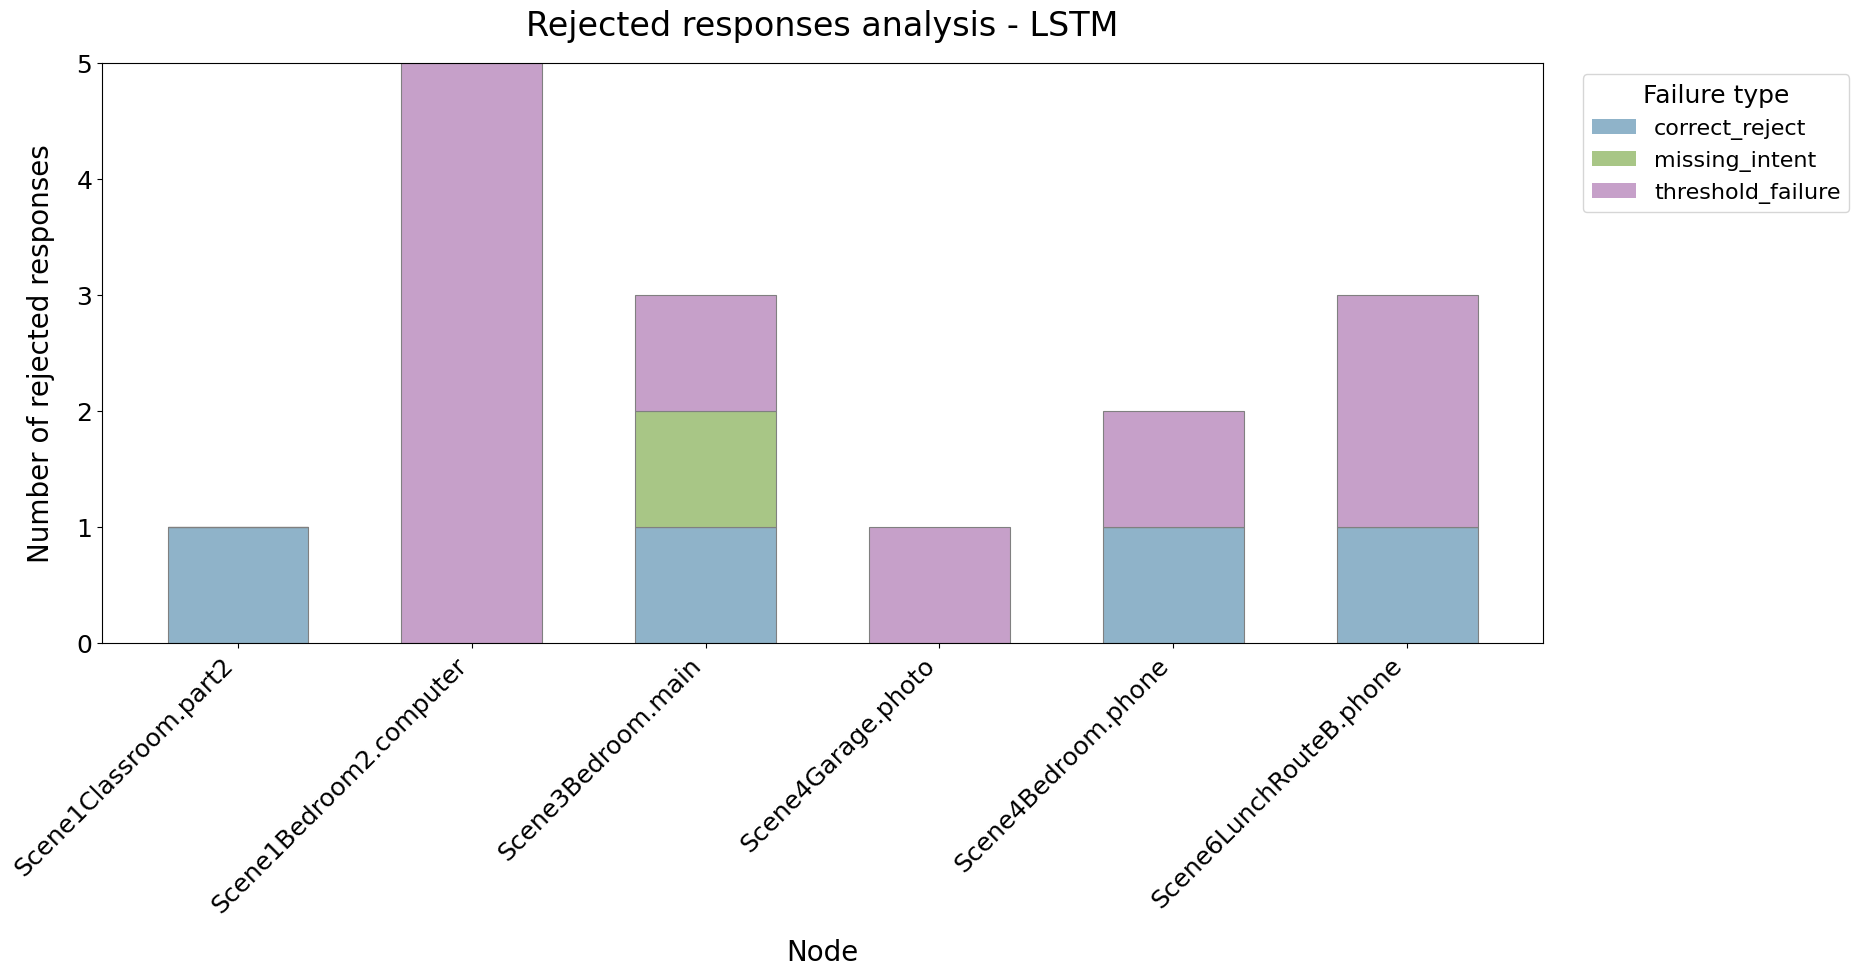

In [9]:
failure_colors = {
    "correct_reject": "#8FB3C9",       # azul suave
    "ambiguous_case": "#E6B89C",       # naranja/beige suave
    "missing_intent": "#A8C686",       # verde suave
    "threshold_failure": "#C6A0C9"     # morado suave
}

failure_types = list(failure_colors)

# Asignar nuevos nombres
def classify_failure(row):
    if row["valid"] == "invalid":
        return "correct_reject"

    if row["valid"] == "unclear":
        return "ambiguous_case"

    if row["valid"] == "new_intent":
        return "missing_intent"

    if row["valid"] == "existing_intent":
        return "threshold_failure"


df["failure_type"] = df.apply(classify_failure, axis=1)

summary = (
    df.groupby(["node", "method", "failure_type"])
      .size()
      .reset_index(name="count")
)

methods = sorted(df["method"].unique())

# Lista de nodos
nodes = [
    node for node in node_order
    if node in summary["node"].unique()
]

# Escala Y con el máximo valor
max_y = (
    summary
    .groupby(["method", "node"])["count"]
    .sum()
    .max()
)

# Se hace un pelín más grande para que las barras no choquen con el borde
max_y = int(max_y * 1.1)

def plot_method(method: str):
    data = (
        summary[summary.method == method]
        .pivot_table(
            index="node",
            columns="failure_type",
            values="count",
            fill_value=0
        )
        .reindex(nodes, fill_value=0)
        .reindex(columns=failure_types, fill_value=0)
    )

    x = np.arange(len(nodes))

    fig, ax = plt.subplots(
        figsize=(22, 10)
    )

    bottom = np.zeros(len(nodes))

    for failure, values in data.items():
        ax.bar(
            x,
            values,
            width=0.6,
            bottom=bottom,
            color=failure_colors[failure],
            edgecolor="gray",
            linewidth=0.8
        )

        bottom += values.values

    # Eje X
    ax.set_xticks(x)

    ax.set_xticklabels(
        nodes,
        rotation=45,
        ha="right",
        fontsize=18
    )

    # Eje Y
    ax.tick_params(
        axis="y",
        labelsize=18
    )

    # Mostrar solo números enteros porque son conteos
    ax.yaxis.set_major_locator(
        MaxNLocator(integer=True)
    )

    # Misma escala Y en todas las gráficas
    ax.set_ylim(
        0,
        max_y
    )

    # Etiquetas y título
    ax.set_xlabel(
        "Node",
        fontsize=20,
        labelpad=15
    )

    ax.set_ylabel(
        "Number of rejected responses",
        fontsize=20,
        labelpad=15
    )

    ax.set_title(
        f"Rejected responses analysis - {method.upper()}",
        fontsize=24,
        pad=20
    )

    legend_handles = [
        Patch(
            facecolor=failure_colors[failure],
            label=failure
        )
        for failure in failure_types
        if failure in data.columns and data[failure].sum() > 0
    ]

    # Leyenda
    ax.legend(
        handles=legend_handles,
        title="Failure type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=16,
        title_fontsize=18
    )

    # Márgenes
    plt.subplots_adjust(
        right=0.78,
        bottom=0.30
    )

    plt.show()

# Crear una figura por método
for method in methods:
    plot_method(method)


In [10]:
print(df["failure_type"].value_counts())


failure_type
threshold_failure    10
correct_reject        4
missing_intent        1
Name: count, dtype: int64


In [11]:
df_eval = df[
    (df["valid"] == "existing_intent") &
    (df["has_multiple_intents"] == True)
].copy()

# Solo consideramos métricas donde hay un intent esperado
df_eval["correct"] = (
    df_eval["predicted_intent"] == df_eval["annotated_intent"]
)

result = (
    df_eval.groupby(["node", "method"])
    .agg(
        total=("correct", "size"),
        correct_predictions=("correct", "sum")
    )
)

result["errors"] = result["total"] - result["correct_predictions"]

result["accuracy_%"] = (
    result["correct_predictions"] / result["total"] * 100
).round(2)

display(result.reset_index())


,node,method,total,correct_predictions,errors,accuracy_%
0,Scene1Bedroom2.computer,lstm,5,3,2,60.0
1,Scene3Bedroom.main,lstm,1,0,1,0.0
2,Scene4Garage.photo,lstm,1,0,1,0.0


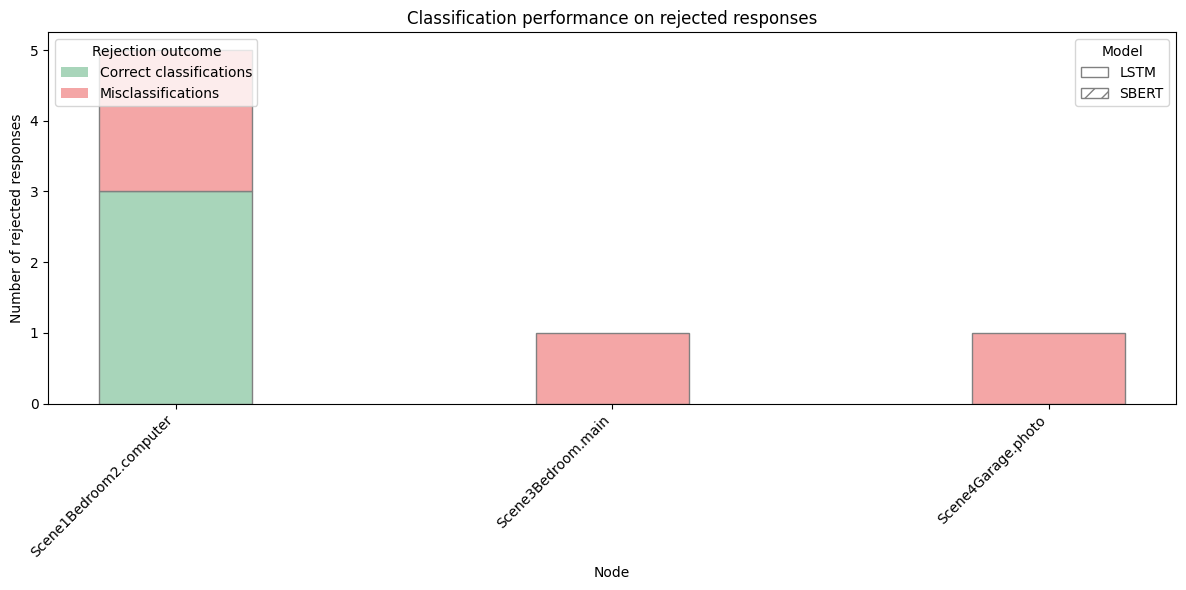

In [12]:
plot_df = result.reset_index()

nodes = [
    node for node in node_order
    if node in plot_df["node"].unique()
]

methods = plot_df["method"].unique()

x = np.arange(len(nodes))
width = 0.35

# Soft colors
correct_color = "#A8D5BA"
error_color = "#F4A6A6"

plt.figure(figsize=(12, 6))

for i, method in enumerate(methods):

    method_df = (
        plot_df[plot_df["method"] == method]
        .set_index("node")
        .reindex(nodes)
        .fillna(0)
    )

    offset = (i - (len(methods)-1)/2) * width

    hatch = "//" if method.lower() == "sbert" else ""

    # Predicciones correctas
    plt.bar(
        x + offset,
        method_df["correct_predictions"],
        width,
        color=correct_color,
        hatch=hatch,
        edgecolor="gray",
        label=f"{method} - Correct"
    )

    # Erorres
    plt.bar(
        x + offset,
        method_df["errors"],
        width,
        bottom=method_df["correct_predictions"],
        color=error_color,
        hatch=hatch,
        edgecolor="gray",
        label=f"{method} - Errors"
    )


plt.xticks(x, nodes, rotation=45, ha="right")
plt.ylabel("Number of rejected responses")
plt.xlabel("Node")
plt.title("Classification performance on rejected responses")

plt.gca().yaxis.set_major_locator(
    MaxNLocator(integer=True)
)

# Resultado de las predicciones
error_legend  = [
    Patch(facecolor=correct_color, label="Correct classifications"),
    Patch(facecolor=error_color, label="Misclassifications")
]

legend1 = plt.legend(
    handles=error_legend ,
    loc="upper left",
    title="Rejection outcome"
)

plt.gca().add_artist(legend1)

# Métodos
method_legend = [
    Patch(facecolor="white", edgecolor="gray", label="LSTM"),
    Patch(facecolor="white", edgecolor="gray", hatch="//", label="SBERT")
]

plt.legend(
    handles=method_legend,
    loc="upper right",
    title="Model"
)

plt.tight_layout()
plt.show()
